# KNN Assignment — Shared Template

**How to use this notebook (read before editing):**
1. In Colab, go to **File → Save a copy in Drive**. Do NOT edit this master copy.
2. Rename your copy with your name + dataset, e.g. `KNN_Areeba_DatasetA.ipynb`.
3. Only change the **CONFIG** cell below (dataset name, Kaggle path, target column). Everything else runs automatically.
4. At the end, copy the final results table into the shared Google Sheet summary tab.

This notebook:
- Loads a dataset from Kaggle
- Preprocesses it (missing values + scaling)
- Runs KNN with **3 distance metrics**: Euclidean, Manhattan, Minkowski
- Sweeps **K values** for each metric to find the best accuracy
- Prints a final comparison table + the single best result to try to beat the research paper's accuracy

## 0. Setup — install/import libraries

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

pd.set_option('display.max_columns', None)

## 1. CONFIG — the only cell each person needs to edit

In [ ]:
# ---- EDIT THESE 4 LINES FOR YOUR DATASET ----

DATASET_LABEL = "Dataset A"          # e.g. "Dataset A", "Dataset B", "Dataset C"
CSV_PATH = "diabetes.csv"        # path after uploading/downloading the Kaggle CSV in Colab
TARGET_COLUMN = "Outcome"             # name of the label/outcome column in your CSV
PAPER_ACCURACY = 0.8571               # the accuracy reported in your research paper, as a decimal (e.g. 72.13% -> 0.7213)

# K values to try (feel free to widen this range)
K_VALUES = list(range(1, 31, 2))     # 1, 3, 5, ..., 29

# Minkowski p-value (p=1 -> Manhattan, p=2 -> Euclidean; here used only for the 'minkowski' row with p=3 to keep it distinct)
MINKOWSKI_P = 3

## 2. Load the dataset

**Option A — Upload manually:** Run the cell below, click "Choose Files", and pick the CSV you downloaded from Kaggle.

**Option B — Kaggle API (faster, no re-uploading each time):** Uncomment the second cell, add your `kaggle.json` API token, and set the dataset slug.

In [ ]:
# ---- OPTION A: manual upload ----
from google.colab import files
uploaded = files.upload()   # choose your CSV file when prompted
CSV_PATH = list(uploaded.keys())[0]

Saving diabetes.csv to diabetes.csv


In [ ]:
# ---- OPTION B: Kaggle API (uncomment to use instead of Option A) ----

# from google.colab import files
# files.upload()  # upload your kaggle.json here
# !mkdir -p ~/.kaggle
# !cp kaggle.json ~/.kaggle/
# !chmod 600 ~/.kaggle/kaggle.json
#
# KAGGLE_DATASET_SLUG = "uciml/pima-indians-diabetes-database"  # change per dataset
# !kaggle datasets download -d {KAGGLE_DATASET_SLUG} --unzip
# CSV_PATH = "diabetes.csv"  # set to the actual filename after unzip

In [ ]:
df = pd.read_csv(CSV_PATH)
print(f"Shape: {df.shape}")
df.head()

Shape: (768, 9)


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72.0,35,169.5,33.6,0.627,50,1
1,1,85,66.0,29,102.5,26.6,0.351,31,0
2,8,183,64.0,32,169.5,23.3,0.672,32,1
3,1,89,66.0,23,94.0,28.1,0.167,21,0
4,0,137,40.0,35,168.0,43.1,2.288,33,1


## 3. Preprocessing

Handles missing values, encodes any text/categorical columns, separates features (X) from the target (y), and scales the features. Scaling matters a lot for KNN since it's distance-based.

In [ ]:
print("Missing values per column:")
print(df.isnull().sum())

# Simple fill for numeric columns; drop rows only if the target itself is missing
df = df.dropna(subset=[TARGET_COLUMN])
for col in df.columns:
    if col != TARGET_COLUMN and df[col].dtype in ['float64', 'int64']:
        df[col] = df[col].fillna(df[col].median())

Missing values per column:
Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64


In [ ]:
X = df.drop(columns=[TARGET_COLUMN])
y = df[TARGET_COLUMN]

# Encode any non-numeric feature columns
for col in X.columns:
    if X[col].dtype == 'object':
        X[col] = LabelEncoder().fit_transform(X[col])

# Encode target if it's text (e.g. 'M'/'B', 'yes'/'no')
if y.dtype == 'object':
    y = LabelEncoder().fit_transform(y)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Train size: {X_train_scaled.shape[0]}, Test size: {X_test_scaled.shape[0]}")

Train size: 614, Test size: 154


## 4. KNN across 3 distance metrics + K sweep

For each distance metric (Euclidean, Manhattan, Minkowski) we try every K in `K_VALUES` and record the accuracy, so we can see the effect of K and pick the best combination.

In [ ]:
distance_metrics = {
    "euclidean": {"metric": "minkowski", "p": 2},
    "manhattan": {"metric": "minkowski", "p": 1},
    "minkowski": {"metric": "minkowski", "p": MINKOWSKI_P},
}

results = []  # will hold rows: distance, k, accuracy

for dist_name, params in distance_metrics.items():
    for k in K_VALUES:
        model = KNeighborsClassifier(n_neighbors=k, metric=params["metric"], p=params["p"])
        model.fit(X_train_scaled, y_train)
        preds = model.predict(X_test_scaled)
        acc = accuracy_score(y_test, preds)
        results.append({"distance": dist_name, "k": k, "accuracy": acc})

results_df = pd.DataFrame(results)
results_df.head()

,distance,k,accuracy
0,euclidean,1,0.805195
1,euclidean,3,0.772727
2,euclidean,5,0.811688
3,euclidean,7,0.805195
4,euclidean,9,0.798701


## 5. Best K per distance metric

In [ ]:
best_per_metric = results_df.loc[results_df.groupby('distance')['accuracy'].idxmax()].reset_index(drop=True)
best_per_metric = best_per_metric.sort_values('accuracy', ascending=False)
print(f"=== Best result per distance metric — {DATASET_LABEL} ===")
best_per_metric

=== Best result per distance metric — Dataset A ===


,distance,k,accuracy
1,manhattan,3,0.863636
0,euclidean,5,0.811688
2,minkowski,1,0.792208


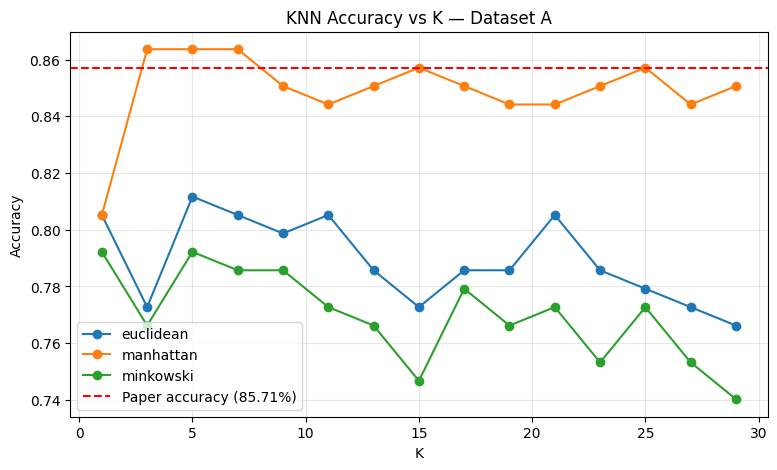

In [ ]:
plt.figure(figsize=(9, 5))
for dist_name in distance_metrics:
    subset = results_df[results_df['distance'] == dist_name]
    plt.plot(subset['k'], subset['accuracy'], marker='o', label=dist_name)

plt.axhline(y=PAPER_ACCURACY, color='red', linestyle='--', label=f'Paper accuracy ({PAPER_ACCURACY:.2%})')
plt.xlabel('K')
plt.ylabel('Accuracy')
plt.title(f'KNN Accuracy vs K — {DATASET_LABEL}')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## 6. Final summary row — copy this into the shared Google Sheet

This matches the assignment's required table: **Euclidean | Manhattan | Minkowski | K | Accuracy**, one row per dataset. Best overall K/accuracy is picked automatically; you can also report all three metrics' individual best-K if your summary needs that level of detail.

In [ ]:
overall_best = best_per_metric.iloc[0]

print(f"Dataset: {DATASET_LABEL}")
print(f"Paper's reported accuracy: {PAPER_ACCURACY:.2%}")
print()
for _, row in best_per_metric.iterrows():
    print(f"  {row['distance'].capitalize():10s} -> best K = {int(row['k']):3d}, accuracy = {row['accuracy']:.2%}")
print()
print(f"BEST OVERALL: {overall_best['distance'].capitalize()} distance, K={int(overall_best['k'])}, "
      f"accuracy = {overall_best['accuracy']:.2%}")

beat_paper = overall_best['accuracy'] > PAPER_ACCURACY
print(f"Beat the paper's accuracy? {'YES ✅' if beat_paper else 'Not yet ❌ — try widening K_VALUES or check preprocessing'}")

summary_row = {
    "Dataset": DATASET_LABEL,
    "Euclidean Accuracy": results_df[results_df['distance']=='euclidean']['accuracy'].max(),
    "Manhattan Accuracy": results_df[results_df['distance']=='manhattan']['accuracy'].max(),
    "Minkowski Accuracy": results_df[results_df['distance']=='minkowski']['accuracy'].max(),
    "Best K": int(overall_best['k']),
    "Best Accuracy": overall_best['accuracy'],
}
pd.DataFrame([summary_row])

Dataset: Dataset A
Paper's reported accuracy: 85.71%

  Manhattan  -> best K =   3, accuracy = 86.36%
  Euclidean  -> best K =   5, accuracy = 81.17%
  Minkowski  -> best K =   1, accuracy = 79.22%

BEST OVERALL: Manhattan distance, K=3, accuracy = 86.36%
Beat the paper's accuracy? YES ✅


,Dataset,Euclidean Accuracy,Manhattan Accuracy,Minkowski Accuracy,Best K,Best Accuracy
0,Dataset A,0.811688,0.863636,0.792208,3,0.863636


Error: Runtime no longer has a reference to this dataframe, please re-run this cell and try again.
